# **EDA Notebook**
IDX Exchange Weeks 2-3 Assignment 

by Jack Phelan : )

In [1]:
#importd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading data from concat-ed csv
listings_df_raw = pd.read_csv("../data/outputs/listings.csv")
sold_df_raw = pd.read_csv("../data/outputs/sold.csv")

/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_13007/2448680216.py:2: DtypeWarning: Columns (0: BuyerOfficeName, 1: BuyerAgentMlsId, 2: BuyerAgentFirstName, 3: BuyerAgentLastName, 4: BuyerOfficeAOR, 5: CoBuyerAgentFirstName, 6: FireplaceYN, 7: LotSizeDimensions, 8: PostalCode, 9: BuyerOfficeName.1, 10: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  listings_df_raw = pd.read_csv("../data/outputs/listings.csv")
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_13007/2448680216.py:3: DtypeWarning: Columns (0: BuyerAgencyCompensationType, 1: latfilled, 2: lonfilled, 3: BuyerAgentAOR, 4: ListAgentAOR, 5: OriginatingSystemName, 6: OriginatingSystemSubName) have mixed types. Specify dtype option on import or set low_memory=False.
  sold_df_raw = pd.read_csv("../data/outputs/sold.csv")


In [3]:
# previews
listings_df_raw.head(5)

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.0,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.0,Huntington Beach Union High,92649,NaN,330.0,1847.0,NaN,16882 Canyon Lane,NaN,NaN
1,999999.0,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.0,Inglewood Unified,90305,NaN,0.0,8508.0,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.0,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.858559,-116.542169,505 E Molino Road,...,2.0,Palm Springs Unified,92262,NaN,NaN,10890.0,NaN,505 E Molino Road,NaN,NaN
3,549000.0,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.0,Los Angeles Unified,90221,NaN,0.0,4113.0,NaN,1736 N Mcdivitt Avenue,NaN,NaN
4,729999.0,1076193391,tony.labellarte@gmail.com,NaN,NaN,Antonio,Labellarte,NaN,NaN,13130 Mercer Street,...,0.0,Los Angeles Unified,91331,NaN,0.0,3551.0,NaN,13130 Mercer Street,NaN,NaN


In [4]:
sold_df_raw.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,True,NaN,NaN,False,265000.0,543251400,michaelg@londonproperties.com,2024-04-02,250000.0,...,93726,0.0,8100.0,NaN,False,False,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,False,429000.0,519252621,robynsong@aol.com,2024-04-30,413700.0,...,92561,0.0,43560.0,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,600000.0,492708527,maryvillamarhomes@gmail.com,2024-04-03,725000.0,...,92173,0.0,10557.0,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,False,NaN,NaN,False,600000.0,1073316150,jeff@whittingtonre.com,2024-04-12,600000.0,...,91977,NaN,8130.0,NaN,True,True,NaN,NaN,NaN,NaN
4,Carpet,NaN,NaN,NaN,False,575000.0,1073312736,erin@mckeonhomes.com,2024-04-08,600000.0,...,94134,154.0,1424.0,NaN,True,True,NaN,NaN,NaN,NaN


# **Listings Analysis**

## **Dataset Overview**

In [5]:
# basic info about data
print("Listings DataFrame Info:")
print(listings_df_raw.shape[0], "rows,", listings_df_raw.shape[1], "columns")
print("Number of float columns:", len(listings_df_raw.select_dtypes(include=['float64']).columns.tolist()))
print("Number of int columns:", len(listings_df_raw.select_dtypes(include=['int64']).columns.tolist()))
print("Number of object columns:", len(listings_df_raw.select_dtypes(include=['object']).columns.tolist()))
print("Number of string columns:", len(listings_df_raw.select_dtypes(include=['string']).columns.tolist()))

Listings DataFrame Info:
426011 rows, 84 columns
Number of float columns: 33
Number of int columns: 4
Number of object columns: 47
Number of string columns: 43


/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_13007/1258458063.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Number of object columns:", len(listings_df_raw.select_dtypes(include=['object']).columns.tolist()))


In [6]:
# specific dtypes 
display(listings_df_raw.dtypes)

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                      str
CloseDate                           str
ClosePrice                      float64
                                 ...   
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                   str
BuyerAgencyCompensationType         str
BuyerAgencyCompensation         float64
Length: 84, dtype: object

In [7]:
listings_df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 426011 entries, 0 to 426010
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             425380 non-null  float64
 1   ListingKey                    426011 non-null  int64  
 2   ListAgentEmail                424966 non-null  str    
 3   CloseDate                     125173 non-null  str    
 4   ClosePrice                    109002 non-null  float64
 5   ListAgentFirstName            422667 non-null  str    
 6   ListAgentLastName             425986 non-null  str    
 7   Latitude                      351296 non-null  float64
 8   Longitude                     351296 non-null  float64
 9   UnparsedAddress               425403 non-null  str    
 10  PropertyType                  426011 non-null  str    
 11  LivingArea                    425581 non-null  float64
 12  ListPrice                     426011 non-null  float64


In [8]:
listings_df_raw.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.0,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.0,Huntington Beach Union High,92649,NaN,330.0,1847.0,NaN,16882 Canyon Lane,NaN,NaN
1,999999.0,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.0,Inglewood Unified,90305,NaN,0.0,8508.0,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.0,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.858559,-116.542169,505 E Molino Road,...,2.0,Palm Springs Unified,92262,NaN,NaN,10890.0,NaN,505 E Molino Road,NaN,NaN
3,549000.0,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.0,Los Angeles Unified,90221,NaN,0.0,4113.0,NaN,1736 N Mcdivitt Avenue,NaN,NaN
4,729999.0,1076193391,tony.labellarte@gmail.com,NaN,NaN,Antonio,Labellarte,NaN,NaN,13130 Mercer Street,...,0.0,Los Angeles Unified,91331,NaN,0.0,3551.0,NaN,13130 Mercer Street,NaN,NaN


In [9]:
METADATA_COLS = ['ListingKey', 'BuyerAgentMlsId', 'ListingKeyNumeric', 'MlsStatus', 'ListingId']

# check datatypes



Notes on datatypes 
- date cols are not actually datetime (but mostly empty anyway so not super important / just ask about it at meeting)
- 

## **Missingness Assessment**

In [10]:
# function for checking df missingness
def get_missing_report(df, index_col=None, flag_high_missing=False, threshold=0.9):
    """
    Returns a DataFrame with the count and percentage of missing values for each column in the input DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame to analyze.
    index_col (str, optional): The column to set as the index of the returned DataFrame. Defaults to None.
    flag_high_missing (bool, optional): Whether to flag columns with high missing values. Defaults to False.
    threshold (float, optional): The threshold for flagging high missing values. Defaults to 0.9.
    
    Returns:
    pd.DataFrame: A DataFrame containing the count and percentage of missing values for each column.
    """
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    missing_report = pd.DataFrame({'column': df.columns, 'missing_count': missing_count, 'pct_missing': missing_percentage})
    if index_col:
        missing_report.set_index(index_col, inplace=True)
    else:
        missing_report.reset_index(drop=True, inplace=True)
    if flag_high_missing:
        missing_report['high_missing'] = missing_report['pct_missing'] > (threshold * 100)
    return missing_report.sort_values(by='missing_count', ascending=False)

In [11]:
listings_missing_report = get_missing_report(listings_df_raw, flag_high_missing=True, threshold=0.9, index_col='column')

display(listings_missing_report)

,missing_count,pct_missing,high_missing
column,,,
TaxAnnualAmount,426011,100.0,True
FireplacesTotal,426011,100.0,True
ElementarySchoolDistrict,426011,100.0,True
BusinessType,426011,100.0,True
TaxYear,426011,100.0,True
...,...,...,...
MlsStatus,0,0.0,False
ListingKey,0,0.0,False
ListingId,0,0.0,False


In [12]:
# collecting cols to drop

COLS_TO_DROP = listings_missing_report[listings_missing_report['high_missing']].index.tolist() # 90% Missing or more

# all high missing and can maybe be acquired from zip code data separatley
SCHOOL_COLS = ['ElementarySchool', 'HighSchool', 'MiddleOrJuniorSchool'] 

# lots of columns that are only filled on listings that were sold - ask about if they should be kept or not

# lots of name columns that could be useless or semi useless its tbd

## **Numeric Distribution Analysis**

Analyze the distribution of key numeric fields: 
- ClosePrice, 
- ListPrice, 
- OriginalListPrice, 
- LivingArea,
- LotSizeAcres, 
- BedroomsTotal, 
- BathroomsTotalInteger, 
- DaysOnMarket, 
- YearBuilt. 




For each field:
-  generate histograms,
-  boxplots,
-  percentile summaries,
-  identify extreme outliers for later handling.

In [13]:

NUMERIC_FIELDS_TO_ANALYZE = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotal",
    "DaysOnMarket",
    "YearBuilt"
]

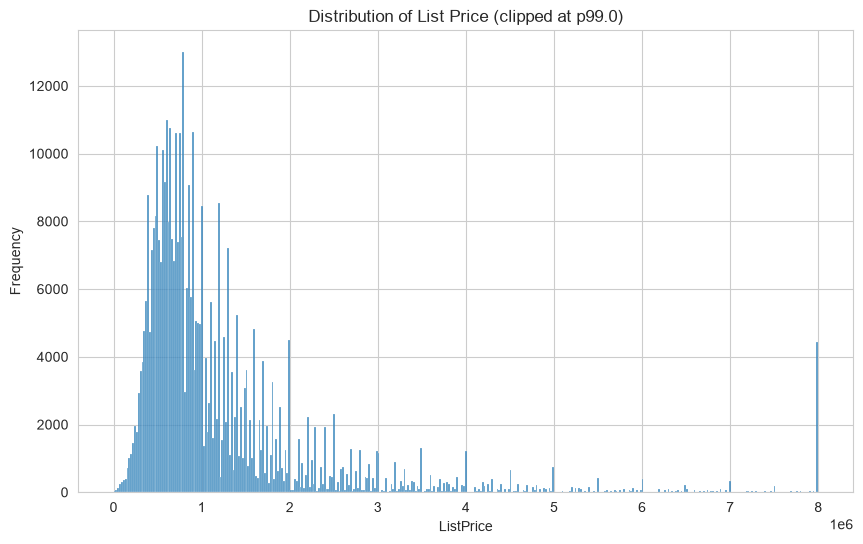

In [15]:
from idx.utils import get_histogram

get_histogram(
    listings_df_raw,
    "ListPrice",
    bins="auto",
    title="Distribution of List Price",
    clip_quantile=0.99
)

# **Sold Analysis**